In [8]:
from matplotlib import pyplot as plt
import numpy as np
import PIL 
import glob
plt.rcParams['font.family']='serif'
import os

In [2]:
files = sorted(glob.glob("VIS_POLI_VS_MAG_SIC/Vis_*X_SiC*.raw"))
print(files)

['VIS_POLI_VS_MAG_SIC/Vis_1.5X_SiC__d0.5m_a15um_p62um_step-4.2_dith23.25_1.raw', 'VIS_POLI_VS_MAG_SIC/Vis_1X_SiC__d0.1m_a15um_p62um_step-4.2_dith23.25_1.raw', 'VIS_POLI_VS_MAG_SIC/Vis_2.5X_SiC__d0.9m_a15um_p62um_step-4.2_dith23.25_1.raw', 'VIS_POLI_VS_MAG_SIC/Vis_2X_SiC__d0.75m_a15um_p62um_step-4.2_dith23.25_1.raw', 'VIS_POLI_VS_MAG_SIC/Vis_3.5X_SiC__d1.08m_a15um_p62um_step-4.2_dith23.25_1.raw', 'VIS_POLI_VS_MAG_SIC/Vis_3X_SiC__d1m_a15um_p62um_step-4.2_dith23.25_1.raw', 'VIS_POLI_VS_MAG_SIC/Vis_4.5X_SiC__d1.17m_a15um_p62um_step-4.2_dith23.25_1.raw', 'VIS_POLI_VS_MAG_SIC/Vis_4X_SiC__d1.13m_a15um_p62um_step-4.2_dith23.25_1.raw', 'VIS_POLI_VS_MAG_SIC/Vis_5.5X_SiC__d1.23m_a15um_p62um_step-4.2_dith23.25_1.raw', 'VIS_POLI_VS_MAG_SIC/Vis_5X_SiC__d1.2m_a15um_p62um_step-4.2_dith23.25_1.raw', 'VIS_POLI_VS_MAG_SIC/Vis_6X_SiC__d1.25m_a15um_p62um_step-4.2_dith23.25_1.raw']


In [3]:
import numpy as np

def compute_visibility(img, block=50):
    vis_values = []

    height, width = img.shape

    for x in range(0, height - block + 1, block):
        for y in range(0, width - block + 1, block):
            region = img[x:x+block, y:y+block]

            mu = np.mean(region)
            sigma = np.std(region)

            if mu > 0:
                vis_values.append(sigma / mu)

    vis_values = np.array(vis_values)

    visibility = np.mean(vis_values)
    visibility_err = np.std(vis_values) / len(vis_values)

    return visibility, visibility_err

In [4]:
vis_results = []
magnifications = []

for file in files:

    # Leer RAW
    data_array = np.fromfile(file, dtype='float32', count=256*256)
    img = data_array.reshape(256, 256)

    # Calcular VIS
    vis = compute_visibility(img)

    vis_results.append(vis)

    # Extraer el número de magnificación del nombre
    mag = file.split("Vis_")[1].split("X")[0]
    magnifications.append(float(mag))

print(magnifications)
print(vis_results)

[1.5, 1.0, 2.5, 2.0, 3.5, 3.0, 4.5, 4.0, 5.5, 5.0, 6.0]
[(0.23906921, 0.002415957748889923), (0.17840779, 0.00140816867351532), (0.2546551, 0.0022882835566997526), (0.25391057, 0.0023881159722805023), (0.24787842, 0.0023482435941696166), (0.24990298, 0.002260473519563675), (0.23556557, 0.002564532458782196), (0.2419946, 0.002400372624397278), (0.22353241, 0.0027198222279548644), (0.23232377, 0.0027376267313957213), (0.21724392, 0.0027154606580734254)]


In [46]:
idx = np.argsort(magnifications)
magnifications = np.array(magnifications)[idx]

vis_results = np.array(vis_results)[idx]

V = vis_results[:, 0]      # visibilidad
V_err = vis_results[:, 1]  # error

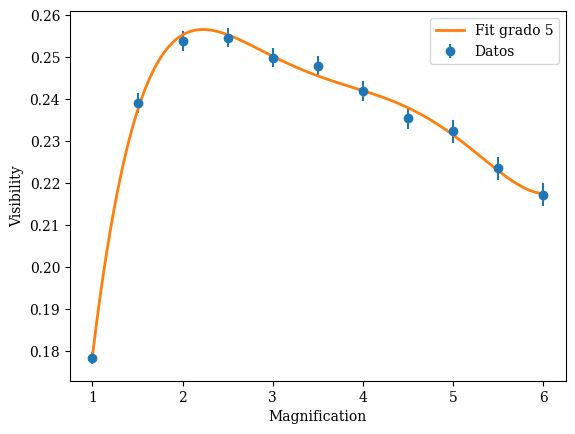

In [53]:


# Ordenar
idx = np.argsort(magnifications)
magnifications = np.array(magnifications)[idx]
vis_results = np.array(vis_results)[idx]

V = vis_results[:, 0]
V_err = vis_results[:, 1]

# Ajuste polinomial
grado = 5
coef = np.polyfit(magnifications, V, grado)
poly = np.poly1d(coef)

# Curva suave
x_fit = np.linspace(np.min(magnifications),
                    np.max(magnifications), 500)
y_fit = poly(x_fit)

# Gráfica
plt.errorbar(magnifications, V, yerr=V_err,
             fmt='o', label='Datos')

plt.plot(x_fit, y_fit, '-', lw=2,
         label=f'Fit grado {grado}')

plt.xlabel("Magnification")
plt.ylabel("Visibility")
plt.legend()
plt.show()

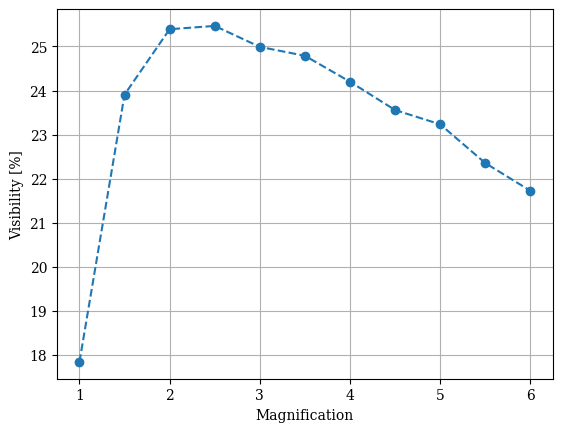

In [48]:
import matplotlib.pyplot as plt

plt.plot(magnifications, V*100, 'o--')
plt.xlabel("Magnification")
plt.ylabel("Visibility [%]")
plt.grid()
plt.show()

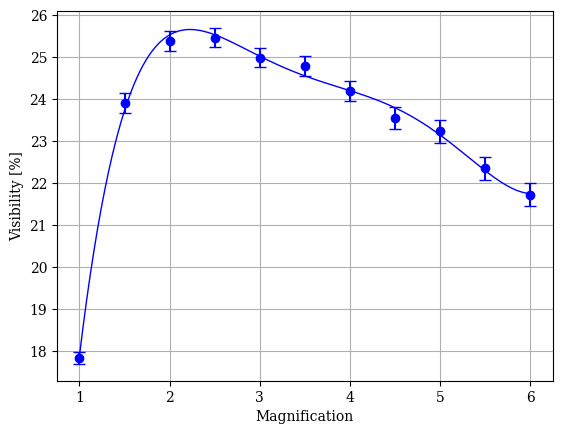

In [58]:
plt.errorbar(
    magnifications,
    V * 100,
    yerr=V_err * 100,
    fmt='o',
    capsize=4,
    color='blue',
)
plt.plot(x_fit, y_fit*100, '-', lw=1, color='blue')

# Línea punteada conectando
#plt.plot(magnifications, V * 100, '--',color='blue')

plt.xlabel("Magnification")
plt.ylabel("Visibility [%]")
plt.grid()
plt.show()

In [59]:
os.makedirs("ARTICLE_RESULTS", exist_ok=True)
plt.savefig("ARTICLE_RESULTS/Visibility_vs_Magnification.png", dpi=300)
plt.savefig("ARTICLE_RESULTS/Visibility_vs_Magnification.pdf", format="pdf", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [60]:

def compute_visibility_x(img, block=50):

    mu_values = []
    gradx_values = []
    grady_values = []

    height, width = img.shape

    # gradiente en x
    grad_x = np.gradient(img, axis=1)
    grad_y = np.gradient(img, axis=0)

    for x in range(0, height - block + 1, block):
        for y in range(0, width - block + 1, block):

            region_I = img[x:x+block, y:y+block]
            region_gradx = grad_x[x:x+block, y:y+block]
            region_grady = grad_y[x:x+block, y:y+block]

            mu = np.mean(region_I)
            sigma_gradx = np.std(region_gradx)
            sigma_grady = np.std(region_grady)

            if mu > 0:
                mu_values.append(mu)
                gradx_values.append(sigma_gradx)
                grady_values.append(sigma_grady)

    mu_values = np.array(mu_values)
    gradx_values = np.array(gradx_values)
    grady_values = np.array(grady_values)

    mean_mu = np.mean(mu_values)
    mean_gradx = np.mean(gradx_values)
    mean_grady = np.mean(grady_values)

    visibility_x = mean_gradx / mean_mu
    visibility_y = mean_grady / mean_mu

    return visibility_x, visibility_y

In [61]:
vis_results_x = []
vis_results_y = []
magnifications = []

for file in files:

    # Leer RAW
    data_array = np.fromfile(file, dtype='float32', count=256*256)
    img = data_array.reshape(256, 256)

    # Calcular VIS
    vis_x, vis_y = compute_visibility_x(img)


    vis_results_x.append(vis_x)
    vis_results_y.append(vis_y)

    # Extraer el número de magnificación del nombre
    mag = file.split("Vis_")[1].split("X")[0]
    magnifications.append(float(mag))

print(magnifications)
print(vis_results_x, vis_results_y)

[1.5, 1.0, 2.5, 2.0, 3.5, 3.0, 4.5, 4.0, 5.5, 5.0, 6.0]
[0.1492269, 0.119024724, 0.13863832, 0.1492045, 0.10994907, 0.12510361, 0.08671924, 0.09747166, 0.07138466, 0.07887436, 0.06439053] [0.14966781, 0.11961025, 0.13854168, 0.1494606, 0.10981154, 0.12481717, 0.08732628, 0.0986544, 0.06995176, 0.079484, 0.064108655]


# SNR vs NUmber_SANDPAPERS

In [62]:
SNR_x = np.array([10.6, 12.51,13.41,14.21,14.65,14.5,15.12])
SNR_y = np.array([10.46,11.9,12.83,13.22,15.2,14.28,15.2])
Number_sands = np.array([1, 2, 3, 4, 6, 8, 10])

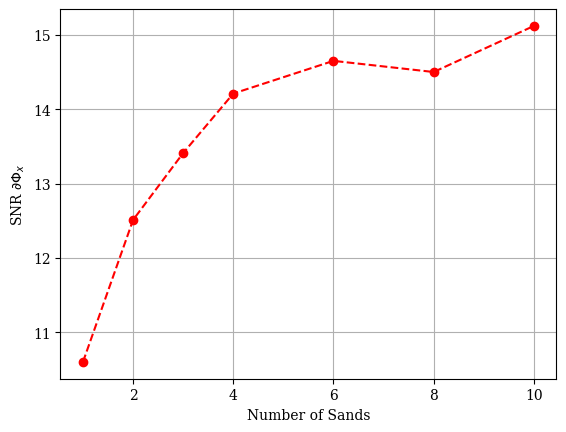

In [63]:
plt.plot(Number_sands, SNR_x, 'o--',color='red')
plt.xlabel("Number of Sands")
plt.ylabel("SNR $\partial \Phi_x$")
plt.grid()
plt.show()

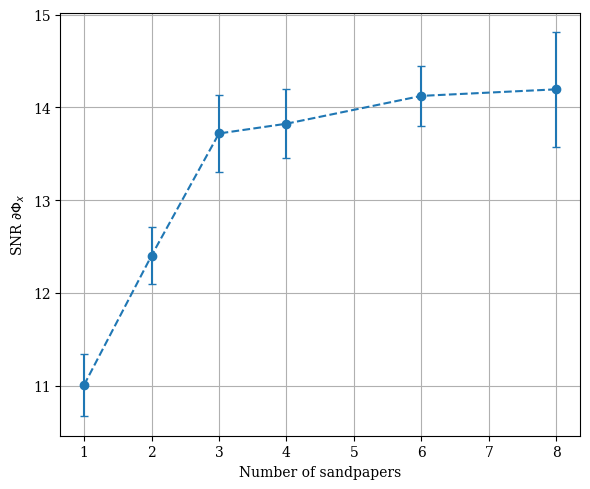

In [80]:

# Cargar archivo (separado por espacios)
data = np.loadtxt('ARTICLE_RESULTS/snrs_y_num_TiC.txt')

# Columnas
x = data[:, 0]
y = data[:, 1]
y_err = data[:, 2]

grado = 3
coef = np.polyfit(x, y, grado)
poly = np.poly1d(coef)

# Curva suave
x_fit = np.linspace(np.min(x),
                    np.max(x), 500)
y_fit = poly(x_fit)
# Plot con barras de error
plt.figure(figsize=(6,5))
plt.errorbar(x, y, yerr=y_err, fmt='o--', capsize=3)
#plt.plot(x_fit, y_fit, '--',color='red')

plt.xlabel('Number of sandpapers')
plt.ylabel('SNR $\partial \Phi_x$')
plt.grid(True)
plt.tight_layout()

plt.show()

In [81]:
plt.savefig("ARTICLE_RESULTS/SNR_Vs_NumberSANDS.png", dpi=300)
plt.savefig("ARTICLE_RESULTS/SNR_Vs_NumberSANDS.pdf", format="pdf", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

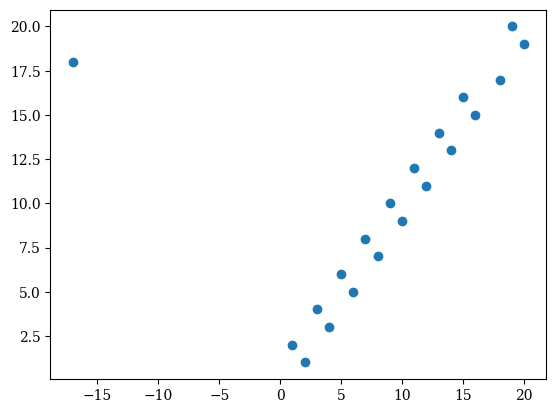

In [66]:
a = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
     11, 12, 13, 14, 15, 16, -17, 18, 19, 20]

b = [2, 1, 4, 3, 6, 5, 8, 7, 10, 9,
     12, 11, 14, 13, 16, 15, 18, 17, 20, 19]

plt.scatter(a, b)
plt.show()